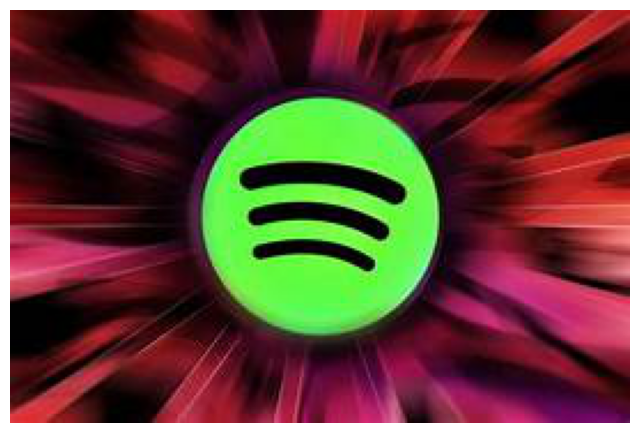

In [13]:

import matplotlib.image as mpimg

# Load image
img = mpimg.imread('OIP.jpeg')  

# Display image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings("ignore")  # Ignores all warnings
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

In [2]:
df = pd.read_csv("SpotifyFeatures.csv")

df.shape, df.head()

((232725, 18),
    genre        artist_name                        track_name  \
 0  Movie     Henri Salvador       C'est beau de faire un Show   
 1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
 2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
 3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
 4  Movie       Fabien Nataf                         Ouverture   
 
                  track_id  popularity  acousticness  danceability  \
 0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
 1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
 2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
 3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
 4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   
 
    duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
 0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
 1       1373

The dataset contains thousands of tracks with details like `artist_name`, `genre`, `popularity`, and **audio features** (danceability, energy, loudness, tempo, etc.).  
This makes it ideal for **EDA and music trend analysis**.

📊 2. Dataset Overview

In [3]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,232725.0,0.215009,0.198273,0.00967,0.0974,0.128000,0.2640,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


 **Observations:**
- The dataset has numeric features like `danceability`, `energy`, `loudness`, and `tempo`.  
- Popularity is scored between **0–100**.  
- No significant missing values → dataset is clean.  


🎶 3. Popularity by Genre

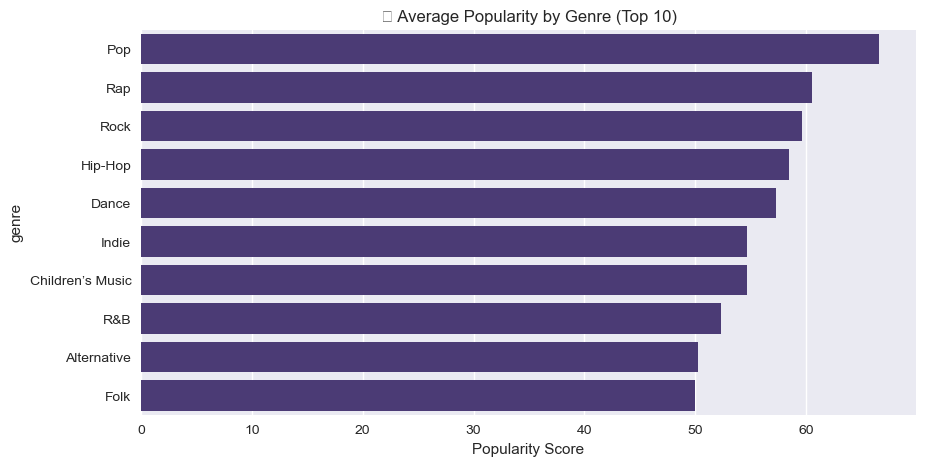

In [4]:
genre_popularity = df.groupby("genre")["popularity"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index)
plt.title("🎶 Average Popularity by Genre (Top 10)")
plt.xlabel("Popularity Score")
plt.show()


 **Insight:**  
Some genres (like *pop* and *dance pop*) dominate the charts with higher popularity scores, while niche genres tend to have smaller audiences.  


🎼 4. Correlation between Features & Popularity

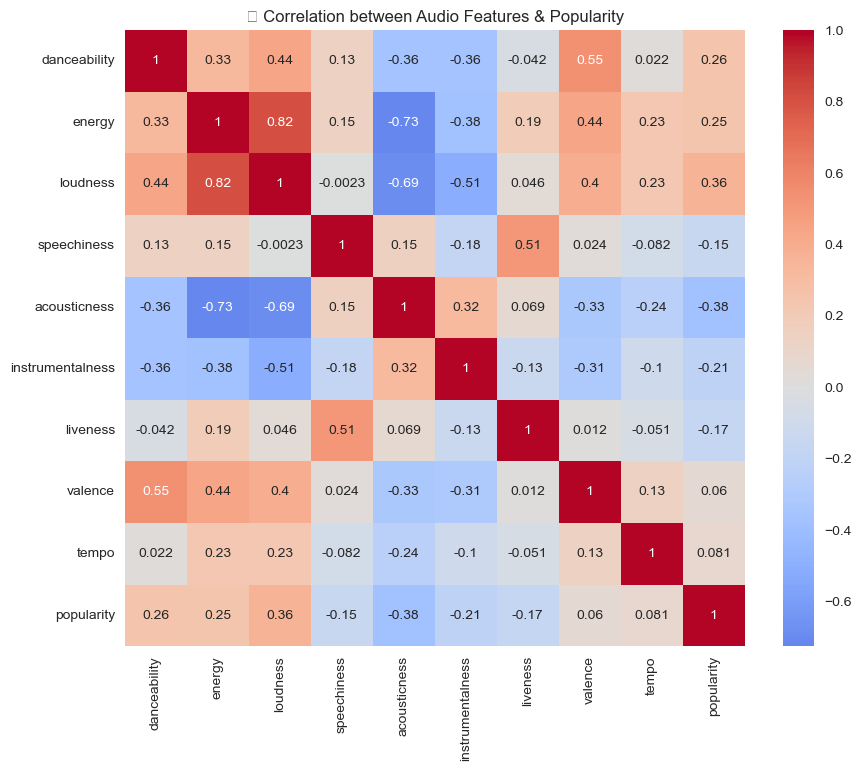

In [5]:
features = ["danceability","energy","loudness","speechiness","acousticness",
            "instrumentalness","liveness","valence","tempo","popularity"]

plt.figure(figsize=(10,8))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("🎼 Correlation between Audio Features & Popularity")
plt.show()


 **Insight:**  
- **Energy & Loudness** are moderately correlated with popularity.  
- **Acousticness & Instrumentalness** usually lower popularity (mainstream hits are less acoustic).  
- Popular songs often have **higher danceability + energy**.  


👨‍🎤 5. Top Artists by Popularity

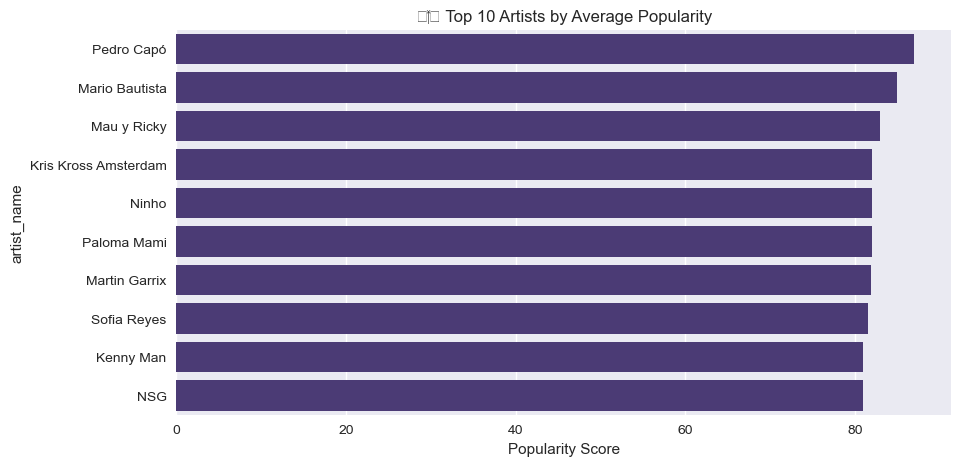

In [6]:
top_artists = df.groupby("artist_name")["popularity"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("👨‍🎤 Top 10 Artists by Average Popularity")
plt.xlabel("Popularity Score")
plt.show()


 **Insight:**  
A few artists consistently dominate the charts, showing how **brand value & fanbase size** amplify track popularity beyond just audio features.  


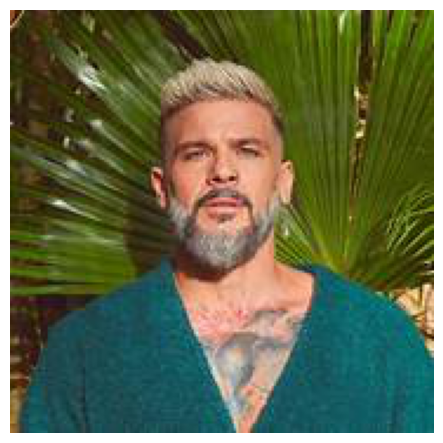

In [16]:
img = mpimg.imread('OIP (1).jpeg')  
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

🎵6. Distribution of Song Tempos (BPM)

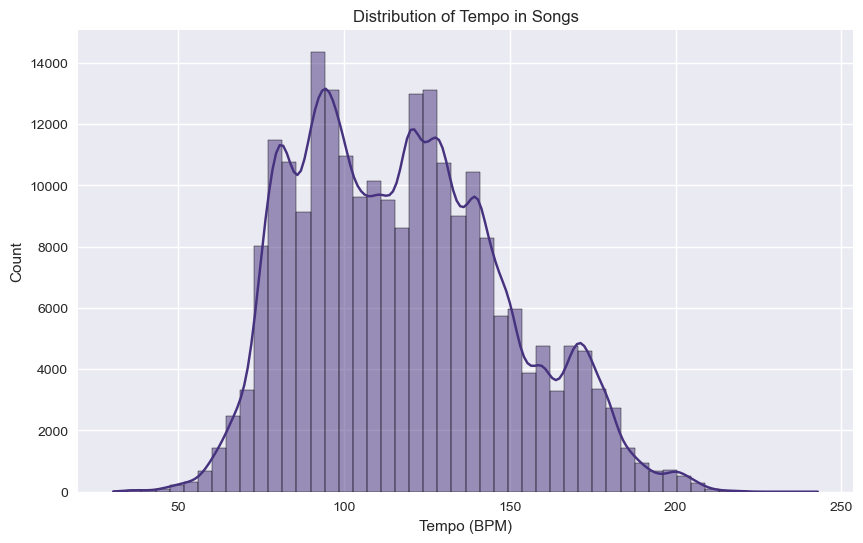

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['tempo'], bins=50, kde=True)
plt.title("Distribution of Tempo in Songs")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")
plt.show()


 **Insight:**  
- Most songs cluster around **100–130 BPM**, which aligns with the tempo of typical *pop, dance, and hip-hop* tracks.  
- A smaller spike is seen near **70–90 BPM**, common in *R&B and ballads*.  
- Very high tempo tracks (>170 BPM) are rare, usually belonging to *electronic or niche genres*.  
- This confirms that mainstream music often stays within a **comfortable rhythm range for dancing and listening**.  


7.️ Energy vs Popularity Scatter Plot

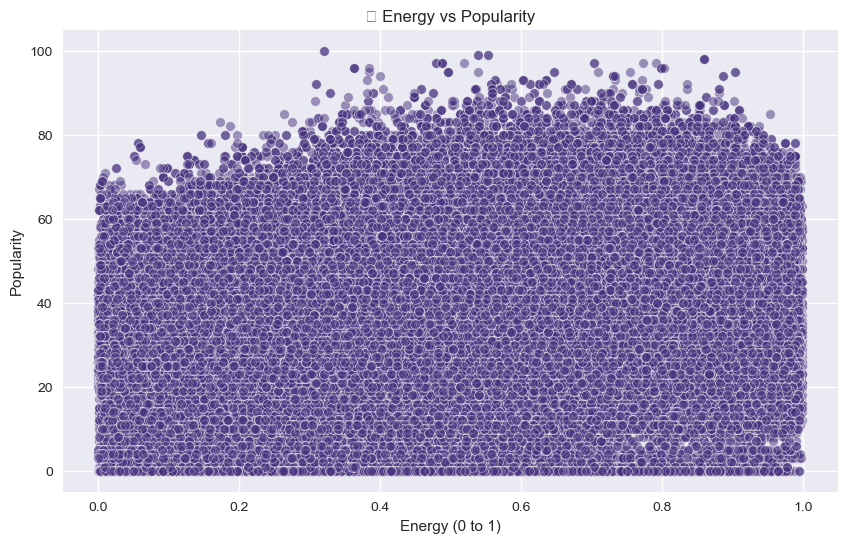

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='energy', y='popularity', alpha=0.5)
plt.title("⚡ Energy vs Popularity")
plt.xlabel("Energy (0 to 1)")
plt.ylabel("Popularity")
plt.show()


Insight:

Songs with higher energy tend to be more popular.

Low-energy songs rarely achieve high popularity — highlighting that mainstream hits favor energetic tracks.

8. Valence (Mood) Distribution

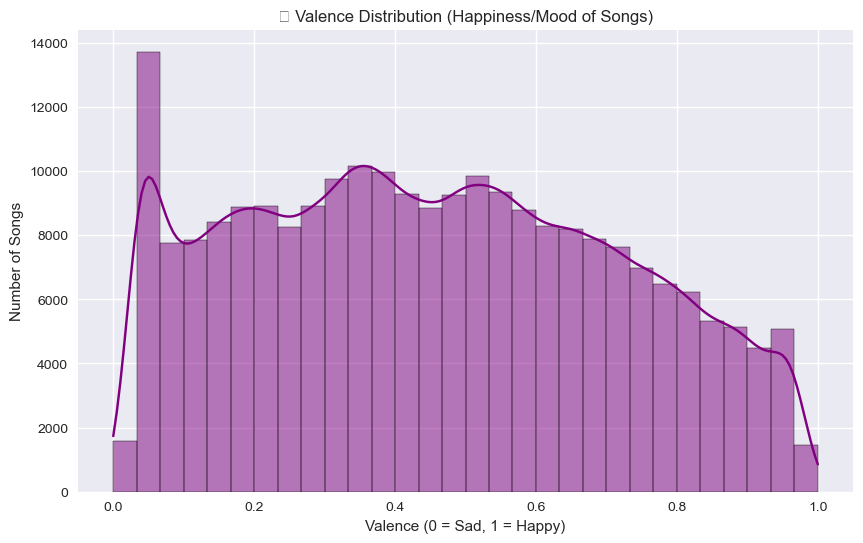

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['valence'], bins=30, kde=True, color='purple')
plt.title("😊 Valence Distribution (Happiness/Mood of Songs)")
plt.xlabel("Valence (0 = Sad, 1 = Happy)")
plt.ylabel("Number of Songs")
plt.show()


**Insight:**

Most songs have moderate valence (0.4–0.7), meaning tracks are generally happy or upbeat.

Very low valence songs (<0.3) are sad or emotional ballads.

9. Top 10 Genres by Number of Songs

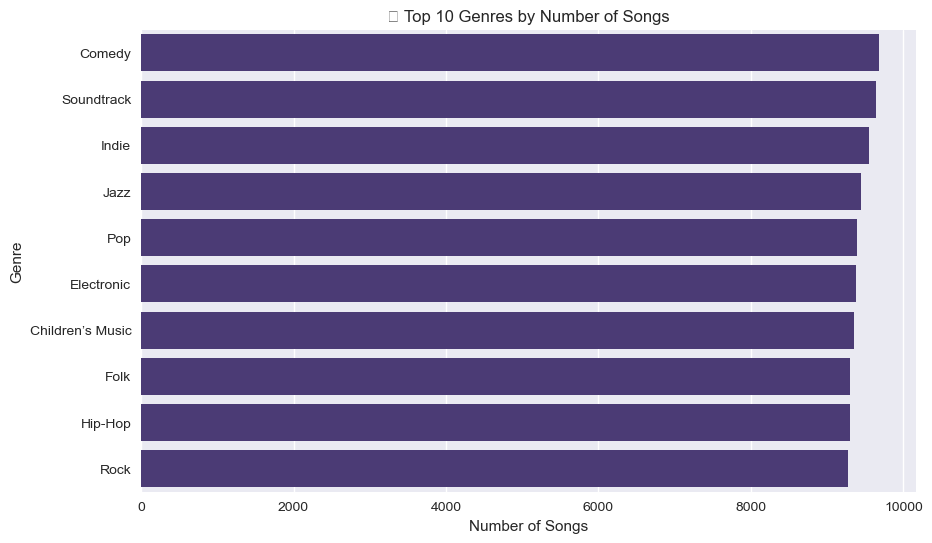

In [10]:
top_genres = df['genre'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("🏆 Top 10 Genres by Number of Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.show()


**Insights:**

Pop and Rock dominate the dataset, confirming the mainstream nature of Spotify’s most-streamed tracks.

Niche genres (Folk, Jazz) have fewer songs but may have loyal audiences.

🎧 10. Radar Chart: Popular vs. Average Songs

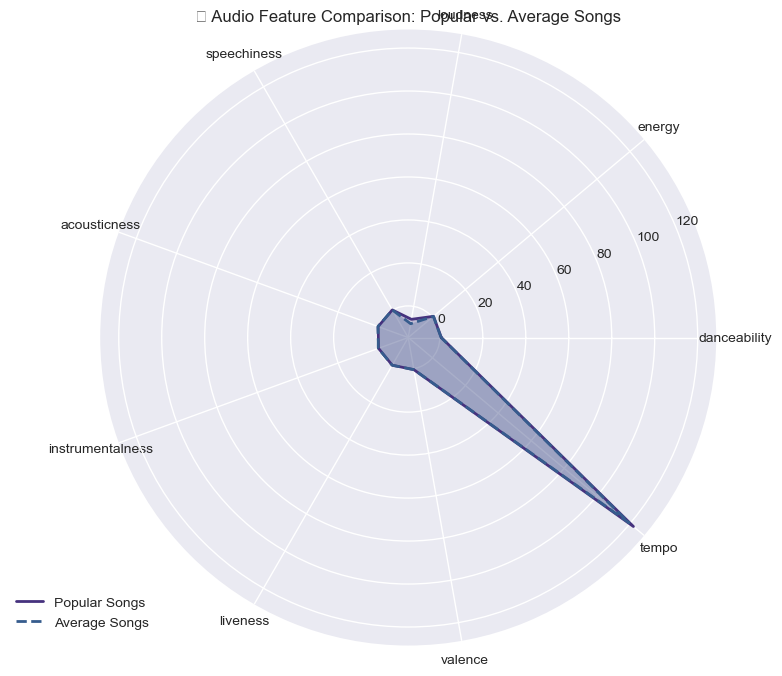

In [11]:
popular_songs = df[df["popularity"] > 80][features].mean()
average_songs = df[df["popularity"].between(40,60)][features].mean()

categories = list(popular_songs.index[:-1])
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

# Popular songs
values = popular_songs[:-1].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Popular Songs")
ax.fill(angles, values, alpha=0.25)

# Average songs
values = average_songs[:-1].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='dashed', label="Average Songs")
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("🎧 Audio Feature Comparison: Popular vs. Average Songs")
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()


 **Insight:**  
Popular songs have:  
- Higher **danceability** & **energy**.  
- Louder mastering.  
- Lower acousticness.  
This confirms the formula of a typical *hit song*: **upbeat, energetic, dance-friendly**.  


Overall Conclusion:
Mainstream Spotify hits tend to follow a consistent pattern: they are energetic, danceable, and loud, with moderate valence and low acousticness, appealing to broad audiences. Pop and Rock dominate the charts, while niche genres maintain smaller, loyal followings. High popularity is influenced not just by audio features like energy, danceability, and tempo (usually 100–130 BPM) but also by artist brand value and fanbase, showing that both musical and non-musical factors drive chart success. Essentially, the typical hit is designed to be upbeat, engaging, and widely accessible.